# Cell 1: Install Required Packages

In [1]:
!pip install nltk

# Cell 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Cell 3: Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving 1429_1.csv to 1429_1.csv


# Cell 4: Load Dataset

In [4]:
df = pd.read_csv("1429_1.csv")

df.head()

/tmp/ipykernel_746/3213301157.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("1429_1.csv")


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


#Cell 5: Select Review Text and Rating

In [5]:
df = df[['reviews.text', 'reviews.rating']]

df.dropna(inplace=True)

df.head()

,reviews.text,reviews.rating
0,This product so far has not disappointed. My c...,5.0
1,great for beginner or experienced person. Boug...,5.0
2,Inexpensive tablet for him to use and learn on...,5.0
3,I've had my Fire HD 8 two weeks now and I love...,4.0
4,I bought this for my grand daughter when she c...,5.0


# Cell 6: Create Sentiment Labels

In [6]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['reviews.rating'].apply(sentiment_label)

df.head()

,reviews.text,reviews.rating,Sentiment
0,This product so far has not disappointed. My c...,5.0,Positive
1,great for beginner or experienced person. Boug...,5.0,Positive
2,Inexpensive tablet for him to use and learn on...,5.0,Positive
3,I've had my Fire HD 8 two weeks now and I love...,4.0,Positive
4,I bought this for my grand daughter when she c...,5.0,Positive


# Cell 7: Visualize Sentiment Distribution

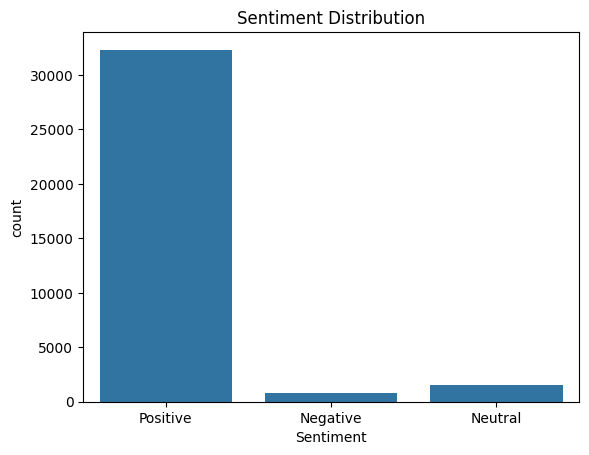

In [7]:
sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

# Cell 8: Text Cleaning

In [8]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['Cleaned_Review'] = df['reviews.text'].apply(clean_text)

# Cell 9: TF-IDF Vectorization

In [9]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Cleaned_Review'])

y = df['Sentiment']

# Cell 10: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Cell 11: Model 1 - Naive Bayes

In [11]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, pred_nb))

Naive Bayes Accuracy:
0.9373375685821542


# Cell 12: Model 2 - SVM

In [12]:
svm = LinearSVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM Accuracy:")
print(accuracy_score(y_test, pred_svm))

SVM Accuracy:
0.9389257868899797


# Cell 13: Compare Models

In [13]:
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, pred_nb))

print("SVM Accuracy:",
      accuracy_score(y_test, pred_svm))

Naive Bayes Accuracy: 0.9373375685821542
SVM Accuracy: 0.9389257868899797


# Cell 14: Classification Report

In [14]:
print(classification_report(
    y_test,
    pred_svm
))

              precision    recall  f1-score   support

    Negative       0.47      0.18      0.26       157
     Neutral       0.38      0.09      0.15       278
    Positive       0.95      0.99      0.97      6491

    accuracy                           0.94      6926
   macro avg       0.60      0.42      0.46      6926
weighted avg       0.91      0.94      0.92      6926



# Cell 15: Test Your Own Review

In [15]:
review = ["This product is amazing and works perfectly"]

review_vector = tfidf.transform(review)

prediction = svm.predict(review_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive
